# 04 — Explainability
**Credit Risk Scoring Pipeline | Project 1**

We use SHAP (SHapley Additive exPlanations) to explain the LightGBM model.  
SHAP answers two questions:
- **Global:** which features matter most across all applicants?
- **Local:** why did the model give *this* applicant a high risk score?

This kind of explanation is required by regulators (e.g. FCA) when a model affects a credit decision.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.credit_risk.features.selector import CreditRiskFeatureSelector
from sklearn.model_selection import train_test_split

FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
RANDOM_STATE = 42

print('Libraries loaded.')


Libraries loaded.


## Step 1 — Load Model and Data

In [2]:
# Load the model bundle saved in notebook 03
with open('../outputs/best_model_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

sel       = bundle['selector']
ct        = bundle['preprocessor']
model     = bundle['model']
num_cols  = bundle['num_cols']
cat_cols  = bundle['cat_cols']

print(f'Model loaded. Test ROC-AUC: {bundle["test_roc_auc"]}')

# Rebuild the same train/test split as notebook 03
df = pd.read_csv('../data/processed/features_engineered.csv')
X  = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y  = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_test_sel  = sel.transform(X_test)
X_test_proc = ct.transform(X_test_sel)

# Get feature names after preprocessing
feature_names = ct.get_feature_names_out()
print(f'Feature count after preprocessing: {len(feature_names)}')


Model loaded. Test ROC-AUC: 0.754


Feature count after preprocessing: 52


## Step 2 — Global Explanations

SHAP summary plot shows which features push predictions up or down across the whole test set.

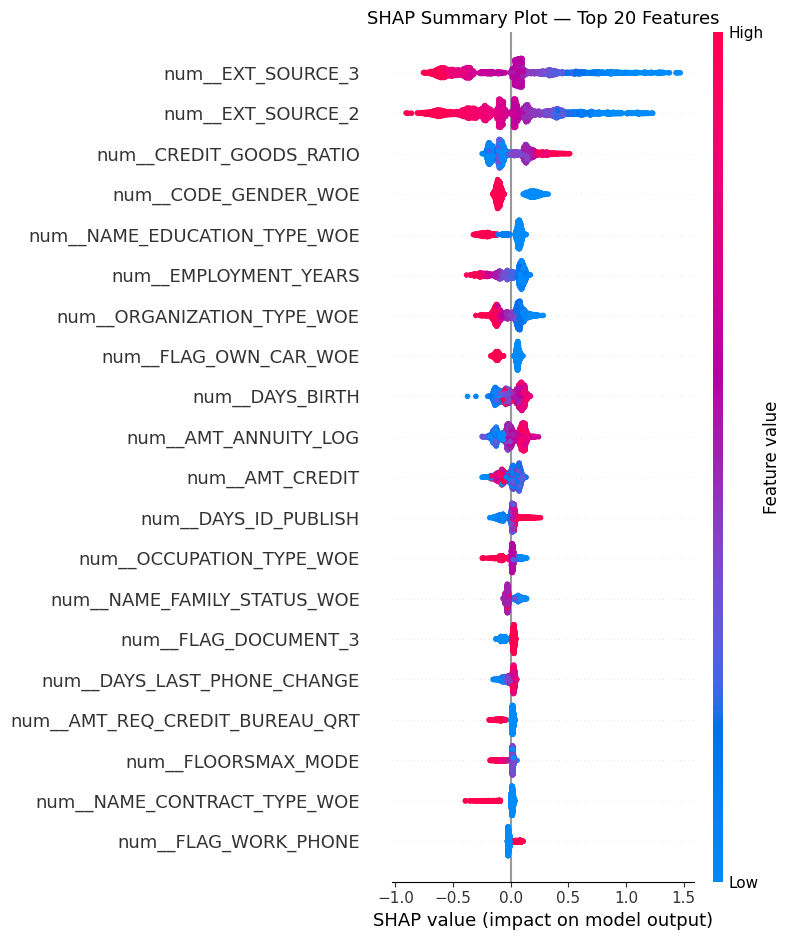

Saved: outputs/figures/04_shap_summary.png


In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

# Use a sample for faster plots — 2,000 applicants is enough for global patterns
SAMPLE_SIZE = 2000
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_proc), SAMPLE_SIZE, replace=False)
sv_sample  = shap_values[idx]
X_sample   = X_test_proc[idx]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_sample, X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Top 20 Features', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_shap_summary.png')


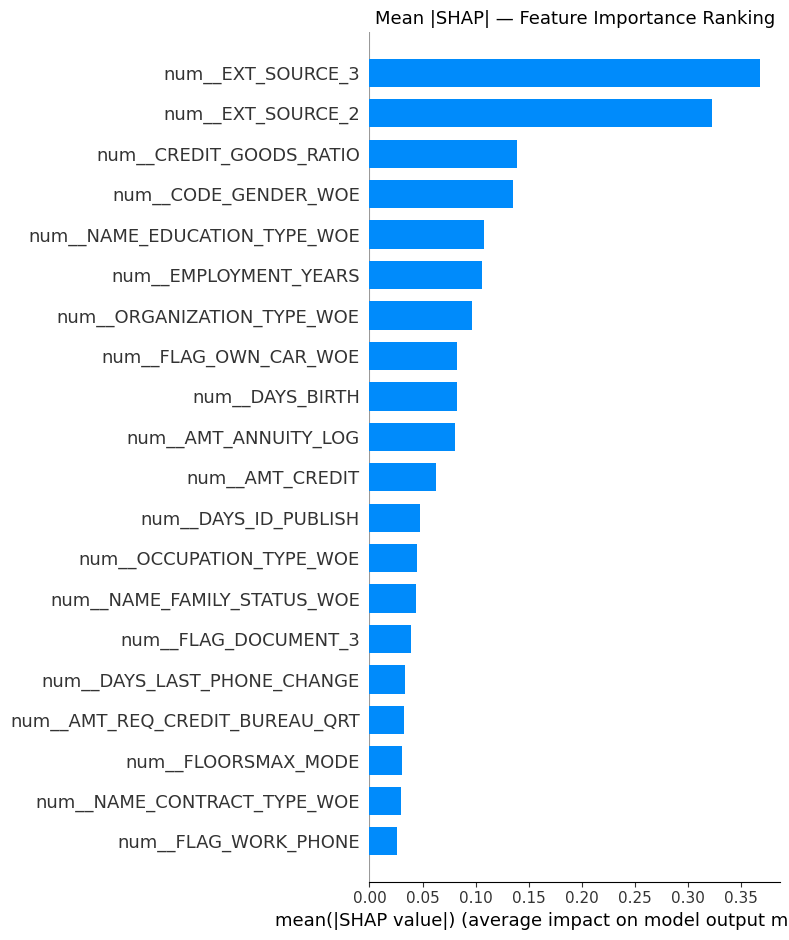

In [4]:
# Bar plot shows mean absolute SHAP — a simple ranking of feature importance
plt.figure(figsize=(9, 7))
shap.summary_plot(
    sv_sample, X_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean |SHAP| — Feature Importance Ranking', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3 — Dependence Plots

A dependence plot shows how one feature affects the model output.  
The colour shows a second feature — this reveals interaction effects.


Top 3 features: ['num__EXT_SOURCE_3', 'num__EXT_SOURCE_2', 'num__CREDIT_GOODS_RATIO']


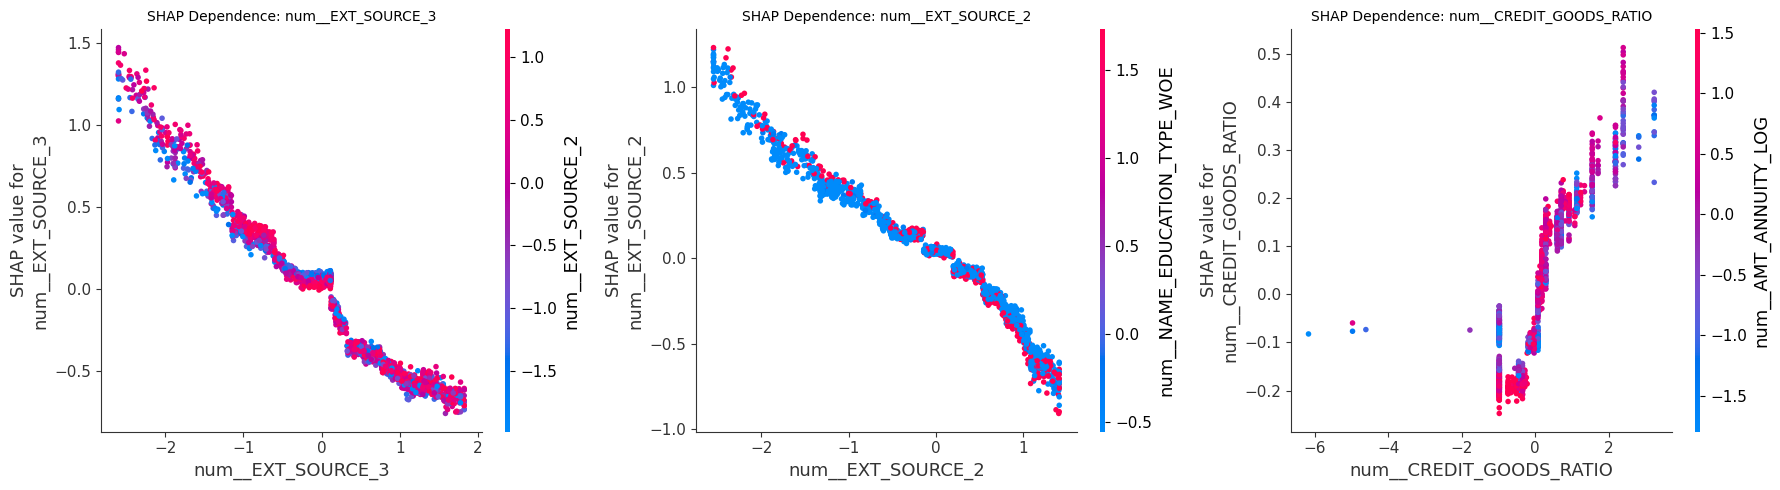

Saved: outputs/figures/04_shap_dependence.png


In [5]:
# Find the top 3 features by mean |SHAP| for dependence plots
mean_abs_shap = np.abs(sv_sample).mean(axis=0)
top3_idx = mean_abs_shap.argsort()[::-1][:3]
top3_names = [feature_names[i] for i in top3_idx]
print('Top 3 features:', top3_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat_name in zip(axes, top3_names):
    feat_idx = list(feature_names).index(feat_name)
    shap.dependence_plot(
        feat_idx, sv_sample, X_sample,
        feature_names=feature_names,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feat_name}', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_shap_dependence.png')


## Step 4 — Local Explanations

A waterfall plot explains a single applicant's prediction.  
It shows which features increased or decreased their risk score.  
This is the kind of output a credit officer would see to understand a model decision.


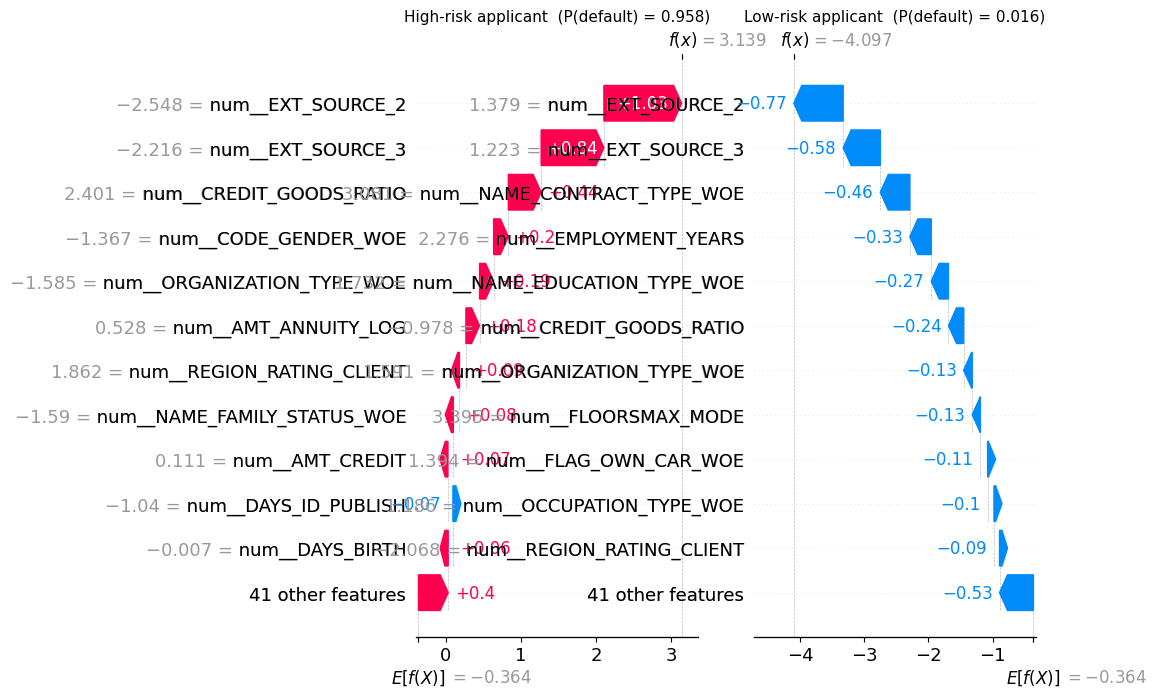

Saved: outputs/figures/04_shap_waterfall.png


In [6]:
# Pick one high-risk and one low-risk applicant from the test set
y_proba_test = model.predict_proba(X_test_proc)[:, 1]

high_risk_idx = y_proba_test.argmax()
low_risk_idx  = y_proba_test.argmin()

shap_exp = shap.Explanation(
    values     = shap_values,
    base_values= explainer.expected_value,
    data       = X_test_proc,
    feature_names=list(feature_names),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.waterfall_plot(shap_exp[high_risk_idx], max_display=12, show=False)
axes[0].set_title(f'High-risk applicant  (P(default) = {y_proba_test[high_risk_idx]:.3f})', fontsize=11)

plt.sca(axes[1])
shap.waterfall_plot(shap_exp[low_risk_idx], max_display=12, show=False)
axes[1].set_title(f'Low-risk applicant  (P(default) = {y_proba_test[low_risk_idx]:.3f})', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_shap_waterfall.png')


## Step 5 — Save SHAP Values

In [7]:
# Save SHAP values and feature names for use in notebook 05
shap_output = {
    'shap_values'  : shap_values,
    'feature_names': list(feature_names),
    'y_proba'      : y_proba_test,
    'y_test'       : y_test.values,
    'expected_value': float(explainer.expected_value),
}
with open('../outputs/shap_output.pkl', 'wb') as f:
    pickle.dump(shap_output, f)

print('SHAP output saved to outputs/shap_output.pkl')
print(f'SHAP array shape: {shap_values.shape}')
print(f'Expected value (base rate in log-odds): {explainer.expected_value:.4f}')


SHAP output saved to outputs/shap_output.pkl
SHAP array shape: (61503, 52)
Expected value (base rate in log-odds): -0.3637
